In [1]:
import spikeinterface.full as si
import probeinterface as pif
import numpy as np
from probeinterface.plotting import plot_probe
import matplotlib.pyplot as plt
import scipy.io as scio
import os
import json
import paramiko
import subprocess
import re
from scp import SCPClient

In [2]:
%matplotlib widget

# Ideally you want to run Catgt at this point, if you haven't already
```
C:\CatGT-win/CatGT.exe -dir=D:\NPX_Data\M465\sourcedata\sub-M465 -run=M465-2024-01-31 -g=0 -t=0 -prb_fld -t_miss_ok -ni -ap -prb=0 -dest=D:\NPX_Data\M465\custom_preprocessed\M465-2024-01-31
```
For a 2 probe session, the command changes slightly
```
C:\CatGT-win/CatGT.exe -dir=D:\NPX_Data\OdorPixels\Pilot1\M465\sourcedata\sub-M465 -run=M465-2024-02-02 -g=0 -t=0 -prb_fld -t_miss_ok -ni -ap -prb='0,1' -dest=D:\NPX_Data\OdorPixels\Pilot1\M465\preprocessed\M465-2024-02-02
```
- VERY IMPORTANT!! Do not apply global CAR to be able to use LFPs later
- Adding the option `-no_autosync` will not extract the sync file stamps from the nidq, or the imec streams
- Set the destination to a different folder, outside of the parent folder, because spikeinterface can't read when t0 and tcat files are inside the same folder. Optionally do not set the `-dest` parameter, and just delete the *g0_t0.imec.ap.bin
- The 'run' parameter must not include "g0"
- The destination folder must not exist, but the its parent folder must (In this case D:\NPX_data\M483 should exist, but **NOT** D:\NPX_data\M483\M483-2024-01-22_tcat)


Text(0.5, 1.0, 'NPX 2')

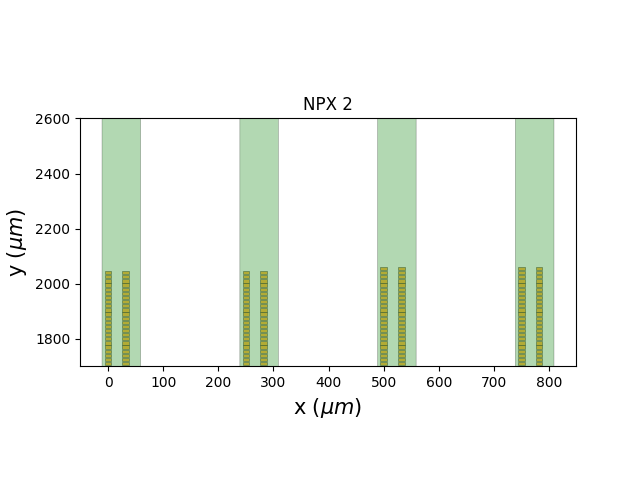

In [3]:
# path to meta file
meta_filename = 'E:\\Task2-SWR\\M542\\catgt_M542-2024-11-04_g0\\M542-2024-11-04_g0_tcat.imec0.ap.meta'
probe = pif.read_spikeglx(meta_filename)
fig,ax = plt.subplots()
plot_probe(probe, ax=ax)
ax.set_aspect(0.5) # Change depending on the probe
ax.set_ylim([1700, 2600]) # Change depending on the probe
ax.set_title('NPX 2') # Change depending on the probe


In [3]:
# Should point to the folder containing the tcat-ed .bin files
raw_rec = si.read_spikeglx('E:\\Task2-SWR\\M542\\catgt_M542-2024-11-04_g0\\', stream_name='imec0.ap')

In [4]:
# raw_rec = si.phase_shift(raw_rec) # DO NOT APPLY phase_shift it tcat has already been applied
rec1 = si.highpass_filter(raw_rec, freq_min=400.)
bad_channel_ids, channel_labels = si.detect_bad_channels(rec1)
print('bad_channel_ids, channel_labels')
for bad_channel_id in bad_channel_ids:
    index = int(bad_channel_id.split('AP')[1])
    print('{}, {}'.format(bad_channel_id, channel_labels[index]))


In [49]:
# Edit the bad_channel_ids array after cross-checking in SpiukeGLX viewer
# Channels labeled 'out' make sense in this case, not sure about the one marked 'dead'
new_array = bad_channel_ids
new_array = np.append(new_array, 'imec0.ap#AP100')
print(new_array)
# bad_channel_ids = new_array

array(['imec0.ap#AP173', 'imec0.ap#AP191', 'imec0.ap#AP222',
       'imec0.ap#AP338', 'imec0.ap#AP100'], dtype='<U64')

In [5]:
# Save the bad_channels as a json so that it can be loaded later
f = open('E:\\Task2-SWR\\M542\\catgt_M542-2024-11-04_g0\\imec0_bad_channels.json', 'w')
json.dump({'bad_channel_ids':bad_channel_ids.tolist()}, f, indent=4)
f.close()

In [5]:
# Load from the json file
f = open('E:\\Task2-SWR\\M542\\catgt_M542-2024-11-04_g0\\imec0_bad_channels.json', 'r')
bad_channel_ids = json.load(f)['bad_channel_ids']
f.close()
rec1  = rec1.remove_channels(bad_channel_ids)

### Setup Kilosort parameters 

In [8]:
ks2_5_path = 'C:\Kilosort2.5' # Change according to the system you are using
si.Kilosort2_5Sorter.set_kilosort2_5_path(ks2_5_path)
si.Kilosort2_5Sorter.is_installed() # Must return true, if not change the path accordingly

Setting KILOSORT2_5_PATH environment variable for subprocess calls to: C:\Kilosort2.5


True

In [9]:
ks2_5_params = si.get_default_sorter_params('kilosort2_5')
ks2_5_params

{'detect_threshold': 6,
 'projection_threshold': [10, 4],
 'preclust_threshold': 8,
 'whiteningRange': 32.0,
 'momentum': [20.0, 400.0],
 'car': True,
 'minFR': 0.1,
 'minfr_goodchannels': 0.1,
 'nblocks': 5,
 'sig': 20,
 'freq_min': 150,
 'sigmaMask': 30,
 'lam': 10.0,
 'nPCs': 3,
 'ntbuff': 64,
 'nfilt_factor': 4,
 'NT': None,
 'AUCsplit': 0.9,
 'do_correction': True,
 'wave_length': 61,
 'keep_good_only': False,
 'skip_kilosort_preprocessing': False,
 'scaleproc': None,
 'save_rez_to_mat': False,
 'delete_tmp_files': ('matlab_files',),
 'delete_recording_dat': False,
 'n_jobs': 1,
 'chunk_duration': '1s',
 'progress_bar': True,
 'mp_context': None,
 'max_threads_per_process': 1}

In [10]:
# Make any changes if needed to these params before dumping to json, example: ks2_params['detect_threshold'] = 4
ks2_5_params['delete_recording_dat'] = True
remote_params = {'bad_channels': bad_channel_ids, 'ks2_5_params': ks2_5_params}

## Running Kilosort locally

In [11]:
si_working_folder = 'F:\\M542-2024-11-04\\'
job_kwargs = dict(n_jobs=20, chunk_duration='1s', progress_bar=True)
rec1 = rec1.save(folder=si_working_folder + 'si_preprocess', format='binary', **job_kwargs)

write_binary_recording 
n_jobs=20 - samples_per_chunk=30,000 - chunk_memory=21.80 MiB - total_memory=436.02 MiB - chunk_duration=1.00s


write_binary_recording:   0%|          | 0/5670 [00:00<?, ?it/s]

In [12]:
ks_working_folder = 'F:\\M542-2024-11-04\\'
si.run_sorter('kilosort2_5', rec1, output_folder=ks_working_folder+'ks2_5_output', verbose=True, remove_existing_folder=False, **ks2_5_params )

C:\Users\mvdmlab\AppData\Local\Temp\ipykernel_2992\101367691.py:2: DeprecationWarning: `output_folder` is deprecated and will be removed in version 0.103.0 Please use folder instead
  si.run_sorter('kilosort2_5', rec1, output_folder=ks_working_folder+'ks2_5_output', verbose=True, remove_existing_folder=False, **ks2_5_params )


RUNNING SHELL SCRIPT: F:\M542-2024-11-04\ks2_5_output\sorter_output\run_kilosort2_5.bat


C:\Users\mvdmlab\Documents\kleaman\odor-pixels\pre-processing>F:



F:\>cd F:\M542-2024-11-04\ks2_5_output\sorter_output 



F:\M542-2024-11-04\ks2_5_output\sorter_output>matlab -nosplash -wait -r "kilosort2_5_master('F:\M542-2024-11-04\ks2_5_output\sorter_output', 'C:\Kilosort2.5')" 

kilosort2_5 run time 2872.31s


KiloSortSortingExtractor: 103 units - 1 segments - 30.0kHz

## Running Kilosort remotely

In [12]:
# Save this where the catgt output folder is located
f = open('E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\remote_params.json', 'w')
json.dump(remote_params, f, indent=4)
f.close()

In [21]:
# Local Parameters
remote_script_filepath = 'E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\remote_sort.py' # Where the remote_sort.py lives inside the catgt output folder
remote_params_filepath = 'E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\remote_params.json' # Where remote_params.json lives
bin_filepath = 'E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-01_g0\\M541-2024-09-05_g0_tcat.imec0.ap.bin' # Where the catgt-ed bin file lives
meta_filepath = 'E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\M541-2024-09-05_g0_tcat.imec0.ap.meta' # Where the catgt-ed meta file lives
local_dest_path = 'E:\\M541\\preprocessed\\M541-2024-09-05\\' # Destination to copy stuff back to

In [22]:
# SSH settings for the remote server with password-based authentication
remote_server = {
    'hostname': 'mvdmlab-deimos',
    'username': 'kleaman',
    'password': 'ozomatl1',
    'dest_path': '/home/kleaman/incoming_ks2',
    'conda_environment': 'spikeinterface',
}
# Connect to the remote server using password-based authentication
remote_client = paramiko.SSHClient()
remote_client.set_missing_host_key_policy(paramiko.AutoAddPolicy())

In [23]:
# Transfer all the required files in one go
try:
    remote_client.connect(
        hostname=remote_server['hostname'],
        username=remote_server['username'],
        password=remote_server['password']
    )
    scp_client = SCPClient(remote_client.get_transport())
    # Transfer the params file
    scp_client.put(remote_script_filepath, remote_server['dest_path'], recursive=True)
    # Transfer the params file
    scp_client.put(remote_params_filepath, remote_server['dest_path'], recursive=True)
    # Transfer the params file
    scp_client.put(bin_filepath, remote_server['dest_path'], recursive=True)
    # Transfer the params file
    scp_client.put(meta_filepath, remote_server['dest_path'], recursive=True)
    print( "All files transferred")

except Exception as e:
    print(e)

finally:
    # Close the SSH connection to the remote server
    remote_client.close()

All files transferred


### Steps to run the script remotely
1. Open an Anaconda **POWERSHELL** Prompt
2. Type the following commands in order:
   ```
   ssh kleaman@mvdmlab-deimos


   cd incoming_ks2
   conda activate spikeinterface
   python remote_sort.py
```
3. Do Not Close that prompt -- wait until it finishes

In [49]:
# Get back the kilosort output from the remote computer
try:
    remote_client.connect(
        hostname=remote_server['hostname'],
        username=remote_server['username'],
        password=remote_server['password']
    )
    scp_client = SCPClient(remote_client.get_transport())
    # Transfer the params file
    scp_client.get('/ks2_t2/ks2_5_output', local_dest_path, recursive=True)
    print( "All files transferred")

except Exception as e:
    print(e)

finally:
    # Close the SSH connection to the remote server
    remote_client.close()

All files transferred


### Steps after Kilosort output is back to the local computer
1. Change params.py to point to the './temp_wh.dat' instead of whatever weird looking thing you see
2. Using the powershell window that you used to login (if you closed it, login again), run the following commands:
   ```
   rm -rf ~/incoming_ks2/*

   rm -rf /ks2_t/*
   ```
3. You can close the window now :)

##  Do manual sorting using phy

In [6]:
# The path should point to the folder that contains phy output
this_rec = rec1 # rec1 is the filtered recording, with the bad channels removed
sorting = si.KiloSortSortingExtractor(folder_path='F:\\M542-2024-11-04\\ks2_5_output\\sorter_output')
sorting

KiloSortSortingExtractor: 100 units - 1 segments - 30.0kHz

In [7]:
# Run the following cell **ONLY** if the notebook was restarted after manual curation

# # This has to match the the details from temp_wh.dat, which is the binary file written
# # by Kilosort. This has to be appended with the appropriate channel ids and channel_locations
# # using rec that has the bad channels removed
this_rec  = si.read_binary('F:\\M542-2024-11-04\\ks2_5_output\\sorter_output\\temp_wh.dat', sampling_frequency=rec1.get_sampling_frequency(), \
                           dtype='int16', num_channels=rec1.get_num_channels())
this_rec.annotate(is_filtered=rec1.is_filtered())
for key in rec1.get_property_keys():
    this_rec.set_property(key, rec1.get_property(key))
this_rec.set_channel_gains(rec1.get_channel_gains())
this_rec.set_probe(rec1.get_probe())
this_rec.annotate(probes_info=rec1.get_annotation('probes_info'))
this_rec.annotate(probe_0_planar_contour=rec1.get_annotation('probe_0_planar_contour'))
sorting.register_recording(this_rec)

## Collating information about clean cells

In [8]:
# KSlabel is Kilosort label, quality is user annotated
keep_idx = np.where(sorting.get_property('quality') == 'good')[0] # np.wher returns a tuple, so the extra '[0]'
keep_units = sorting.unit_ids[keep_idx]
clean_units = sorting.select_units(keep_units)
clean_units_ch = ['imec0.ap#AP' + str(x) for x in clean_units.get_property('ch')]
rec_ch = ['imec0.ap#' + str(x) for x in this_rec.get_property('channel_names')]
keep = [np.where(np.array(rec_ch) == x)[0].tolist() for x in clean_units_ch]
# This is a bug because 'bad channels' shouldn't be present in the first place
tokeep = [x for x,y in enumerate(keep) if y]
if len(tokeep) != len(keep):
    print('Bad channels are present in the clean units!! Weird!!')

keep_idx = keep_idx[np.asarray(tokeep)]
keep_units = sorting.unit_ids[keep_idx]
clean_units = sorting.select_units(keep_units)
clean_units_ch = ['imec0.ap#AP' + str(x) for x in clean_units.get_property('ch')]
rec_ch = ['imec0.ap#' + str(x) for x in this_rec.get_property('channel_names')]
keep = [np.where(np.array(rec_ch) == x)[0][0] for x in clean_units_ch]
clean_spike_train = [clean_units.get_unit_spike_train(x)/clean_units.get_sampling_frequency() \
    for x in clean_units.unit_ids]
clean_unit_ids = [str(x) for x in keep_units]
clean_unit_ids = ['imec0_'+x for x in clean_unit_ids]
clean_depths = clean_units.get_property('depth')
all_locs = this_rec.get_channel_locations()
# final_depths = [x[1] for x in all_locs[keep]] # There seems to be an offset between this and the depth from sorting.get_depths()
clean_unit_sh = [int(x[0]//250) for x in all_locs[keep]]
assert (np.all(clean_unit_sh == this_rec.get_channel_groups()[keep])) # Sanity check

### The below code is to extract the waveforms of the curated neurons (might take some time to run)

In [9]:
job_kwargs = dict(n_jobs=1, chunk_duration='1s', progress_bar=True)
analyzer = si.create_sorting_analyzer(sorting=clean_units, recording=this_rec, folder="F:\\M542-2024-11-04\\clean_sorting", format="binary_folder", sparse=True)
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("spike_amplitudes", peak_sign="pos")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
clean_peak_amp = [amps_data[0][x] for x in clean_units.unit_ids]
wv = analyzer.get_extension(extension_name="waveforms")
clean_waveforms = [np.mean(wv.get_waveforms_one_unit(x), axis=0).T for x in clean_units.unit_ids]
analyzer.delete_extension('spike_amplitudes')
analyzer.compute("spike_amplitudes", peak_sign="neg")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
clean_valley_amp = [amps_data[0][x] for x in clean_units.unit_ids]

C:\Users\mvdmlab\miniconda3\envs\spikeinterface\lib\site-packages\spikeinterface\core\job_tools.py:103: UserWarning: `n_jobs` is not set so parallel processing is disabled! To speed up computations, it is recommended to set n_jobs either globally (with the `spikeinterface.set_global_job_kwargs()` function) or locally (with the `n_jobs` argument). Use `spikeinterface.set_global_job_kwargs?` for more information about job_kwargs.
  warnings.warn(


estimate_sparsity:   0%|          | 0/5671 [00:00<?, ?it/s]

C:\Users\mvdmlab\miniconda3\envs\spikeinterface\lib\site-packages\spikeinterface\core\basesorting.py:264: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms:   0%|          | 0/5671 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/5671 [00:00<?, ?it/s]

### Saving as mat-files

In [12]:
# Saving everything
spikes_mat_fname = 'F:\\M542-2024-11-04\\clean_units_imec0.mat' # add imec0 or imec1 if 2 probes
scio.savemat(spikes_mat_fname, {'depths': clean_depths, 'unit_ids': clean_unit_ids, \
    'channel_ids': clean_units_ch, 'spike_train': clean_spike_train, 'shank_ids': clean_unit_sh,  'mean_waveforms': clean_waveforms, \
                               'peak_amp': clean_peak_amp, 'valley_amp': clean_valley_amp})

### Now for MUA

In [13]:
# KSlabel is Kilosort label, quality is user annotated
keep_idx = np.where(sorting.get_property('quality') == 'mua')[0] # np.wher returns a tuple, so the extra '[0]'
keep_units = sorting.unit_ids[keep_idx]
mua_units = sorting.select_units(keep_units)
mua_units_ch = ['imec0.ap#AP' + str(x) for x in mua_units.get_property('ch')]
rec_ch = ['imec0.ap#' + str(x) for x in this_rec.get_property('channel_names')]
keep = [np.where(np.array(rec_ch) == x)[0].tolist() for x in mua_units_ch]
# This is a bug because 'bad channels' shouldn't be present in the first place
tokeep = [x for x,y in enumerate(keep) if y]
if len(tokeep) != len(keep):
    print('Bad channels are present in the MUA units!! Weird!!')

keep_idx = keep_idx[np.asarray(tokeep)]
keep_units = sorting.unit_ids[keep_idx]
mua_units = sorting.select_units(keep_units)
mua_units_ch = ['imec0.ap#AP' + str(x) for x in mua_units.get_property('ch')]
rec_ch = ['imec0.ap#' + str(x) for x in this_rec.get_property('channel_names')]
keep = [np.where(np.array(rec_ch) == x)[0][0] for x in mua_units_ch]
mua_spike_train = [mua_units.get_unit_spike_train(x)/mua_units.get_sampling_frequency() \
    for x in mua_units.unit_ids]
mua_unit_ids = [str(x) for x in keep_units]
mua_unit_ids = ['imec0_'+x for x in mua_unit_ids]
mua_depths = mua_units.get_property('depth')
all_locs = this_rec.get_channel_locations()
# final_depths = [x[1] for x in all_locs[keep]] # There seems to be an offset between this and the depth from sorting.get_depths()
mua_unit_sh = [int(x[0]//250) for x in all_locs[keep]]
assert (np.all(mua_unit_sh == this_rec.get_channel_groups()[keep])) # Sanity check

### The below code is to extract the waveforms of MUA units, might take a while to run

In [14]:
job_kwargs = dict(n_jobs=1, chunk_duration='1s', progress_bar=True)
analyzer = si.create_sorting_analyzer(sorting=mua_units, recording=this_rec, folder="F:\\M542-2024-11-04\\mua_sorting", format="binary_folder", sparse=True)
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("spike_amplitudes", peak_sign="pos")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
mua_peak_amp = [amps_data[0][x] for x in mua_units.unit_ids]
wv = analyzer.get_extension(extension_name="waveforms")
mua_waveforms = [np.mean(wv.get_waveforms_one_unit(x), axis=0).T for x in mua_units.unit_ids]
analyzer.delete_extension('spike_amplitudes')
analyzer.compute("spike_amplitudes", peak_sign="neg")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
mua_valley_amp = [amps_data[0][x] for x in mua_units.unit_ids]

estimate_sparsity:   0%|          | 0/5671 [00:00<?, ?it/s]

C:\Users\mvdmlab\miniconda3\envs\spikeinterface\lib\site-packages\spikeinterface\core\basesorting.py:264: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms:   0%|          | 0/5671 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/5671 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/5671 [00:00<?, ?it/s]

In [15]:
# Saving everything
spikes_mat_fname = 'F:\\M542-2024-11-04\\mua_units_imec0.mat' # add imec0 or imec1 if 2 probes
scio.savemat(spikes_mat_fname, {'depths': mua_depths, 'unit_ids': mua_unit_ids, \
    'channel_ids': mua_units_ch, 'spike_train': mua_spike_train, 'shank_ids': mua_unit_sh,  'mean_waveforms': mua_waveforms, \
                               'peak_amp': mua_peak_amp, 'valley_amp': mua_valley_amp})

# Run the following if there is a second probe

Text(0.5, 1.0, 'NPX 2')

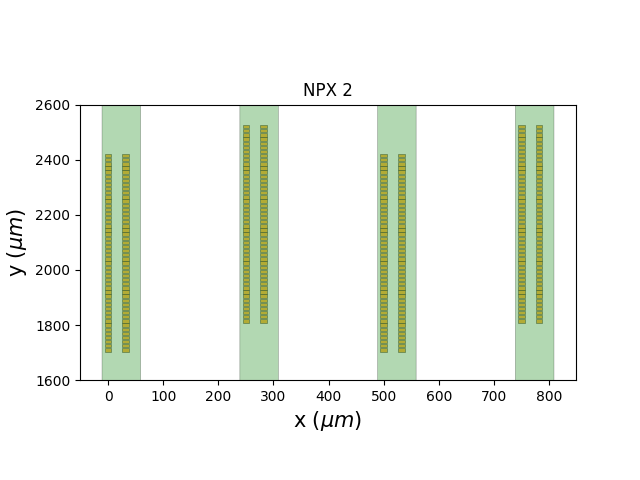

In [20]:
# path to meta file
meta_filename = 'E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\M541-2024-09-05_g0_tcat.imec1.ap.meta'
probe = pif.read_spikeglx(meta_filename)
fig,ax = plt.subplots()
plot_probe(probe, ax=ax)
ax.set_aspect(0.5) # Change depending on the probe
ax.set_ylim([1600, 2600]) # Change depending on the probe
ax.set_title('NPX 2') # Change depending on the probe


In [28]:
# Should point to the folder containing the tcat-ed .bin files
raw_rec2 = si.read_spikeglx('E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\', stream_name='imec1.ap')

In [29]:
# raw_rec2 = si.phase_shift(raw_rec2) # DO NOT APPLY phase_shift it tcat has already been applied
rec2 = si.highpass_filter(raw_rec2, freq_min=400.)
bad_channel_ids2, channel_labels2 = si.detect_bad_channels(rec2)
print('bad_channel_ids, channel_labels')
for bad_channel_id in bad_channel_ids2:
    index = int(bad_channel_id.split('AP')[1])
    print('{}, {}'.format(bad_channel_id, channel_labels2[index]))

In [ ]:
# Edit the bad_channel_ids array after cross-checking in SpiukeGLX viewer
# Channels labeled 'out' make sense in this case, not sure about the one marked 'dead'
new_array2 = bad_channel_ids2
new_array = np.append(new_array2, 'imec0.ap#AP100')
print(new_array2)
# bad_channel_ids2 = new_array2

In [23]:
# Save the bad_channels as a json so that it can be loaded later
f = open('E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\imec1_bad_channels.json', 'w')
json.dump({'bad_channel_ids':bad_channel_ids2.tolist()}, f, indent=4)
f.close()

In [30]:
# Load from the json file
f = open('E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\imec1_bad_channels.json', 'r')
bad_channel_ids2 = json.load(f)['bad_channel_ids']
f.close()
rec2  = rec2.remove_channels(bad_channel_ids2)

### Setup Kilosort parameters 

In [25]:
ks2_5_path = 'C:\\Users\\mvdmlab\\Documents\\GitHub\\Kilosort-2.5' # Change according to the system you are using
si.Kilosort2_5Sorter.set_kilosort2_5_path(ks2_5_path)
si.Kilosort2_5Sorter.is_installed() # Must return true, if not change the path accordingly

Setting KILOSORT2_5_PATH environment variable for subprocess calls to: C:\Users\mvdmlab\Documents\GitHub\Kilosort-2.5


True

In [26]:
ks2_5_params = si.get_default_sorter_params('kilosort2_5')
ks2_5_params

{'detect_threshold': 6,
 'projection_threshold': [10, 4],
 'preclust_threshold': 8,
 'momentum': [20.0, 400.0],
 'car': True,
 'minFR': 0.1,
 'minfr_goodchannels': 0.1,
 'nblocks': 5,
 'sig': 20,
 'freq_min': 150,
 'sigmaMask': 30,
 'lam': 10.0,
 'nPCs': 3,
 'ntbuff': 64,
 'nfilt_factor': 4,
 'NT': None,
 'AUCsplit': 0.9,
 'do_correction': True,
 'wave_length': 61,
 'keep_good_only': False,
 'skip_kilosort_preprocessing': False,
 'scaleproc': None,
 'save_rez_to_mat': False,
 'delete_tmp_files': ('matlab_files',),
 'delete_recording_dat': False,
 'n_jobs': 16,
 'chunk_duration': '1s',
 'progress_bar': True,
 'mp_context': None,
 'max_threads_per_process': 1}

In [27]:
# Make any changes if needed to these params before dumping to json, example: ks2_params['detect_threshold'] = 4
ks2_5_params['delete_recording_dat'] = True
remote_params = {'bad_channels': bad_channel_ids2, 'ks2_5_params': ks2_5_params}

### Running Kilosort locally

In [28]:
si_working_folder2 = 'E:\\M541\\preprocessed\\M541-2024-09-05\\'
job_kwargs = dict(n_jobs=20, chunk_duration='1s', progress_bar=True)
rec2 = rec2.save(folder=si_working_folder2 + 'si_preprocess2', format='binary', **job_kwargs)

write_binary_recording with n_jobs = 20 and chunk_size = 30000


write_binary_recording:   0%|          | 0/6401 [00:00<?, ?it/s]

In [30]:
ks_working_folder2 = 'E:\\M541\\preprocessed\\M541-2024-09-05\\'
si.run_sorter('kilosort2_5', rec2, output_folder=ks_working_folder2+'ks2_5_output2', verbose=True, remove_existing_folder=False, **ks2_5_params )

RUNNING SHELL SCRIPT: E:\M541\preprocessed\M541-2024-09-05\ks2_5_output\sorter_output\run_kilosort2_5.bat


E:\M541\preprocessed\M541-2024-09-05>E:



E:\M541\preprocessed\M541-2024-09-05>cd E:\M541\preprocessed\M541-2024-09-05\ks2_5_output\sorter_output 



E:\M541\preprocessed\M541-2024-09-05\ks2_5_output\sorter_output>matlab -nosplash -log -wait -r "kilosort2_5_master('E:\M541\preprocessed\M541-2024-09-05\ks2_5_output\sorter_output', 'C:\Users\mvdmlab\Documents\GitHub\Kilosort-2.5')" 

Time   0s. Computing whitening matrix.. 

Getting channel whitening matrix... 

Channel-whitening matrix computed. 

Time  40s. Loading raw data and applying filters... 

Time 993s. Finished preprocessing 2927 batches. 

Drift correction ENABLED

pitch is 15 um

0.88 sec, 1 batches, 1983 spikes 

73.44 sec, 101 batches, 174367 spikes 

146.06 sec, 201 batches, 348829 spikes 

218.84 sec, 301 batches, 516575 spikes 

291.61 sec, 401 batches, 679798 spikes 

364.23 sec, 501 batches, 838224 spikes 

436.

KiloSortSortingExtractor: 68 units - 1 segments - 30.0kHz

## Running Kilosort remotely

In [32]:
# Save this where the catgt output folder is located
f = open('E:\\odor-pixels\\Cohort5\\M541\\preprocessed\\M541-2024-08-31\\catgt_M541-2024-08-31_g0\\remote_params.json', 'w')
json.dump(remote_params, f, indent=4)
f.close()

In [33]:
# Local Parameters
remote_script_filepath = 'E:\\odor-pixels\\Cohort5\M541\\preprocessed\\M541-2024-08-31\\catgt_M541-2024-08-31_g0\\remote_sort.py' # Where the remote_sort.py lives inside the catgt output folder
remote_params_filepath = 'E:\\odor-pixels\\Cohort5\M541\\preprocessed\\M541-2024-08-31\\catgt_M541-2024-08-31_g0\\remote_params.json' # Where remote_params.json lives
bin_filepath = 'E:\\odor-pixels\\Cohort5\M541\\preprocessed\\M541-2024-08-31\\catgt_M541-2024-08-31_g0\\M541-2024-08-31_g0_tcat.imec1.ap.bin' # Where the catgt-ed bin file lives
meta_filepath = 'E:\\odor-pixels\\Cohort5\M541\\preprocessed\\M541-2024-08-31\\catgt_M541-2024-08-31_g0\\M541-2024-08-31_g0_tcat.imec1.ap.meta' # Where the catgt-ed meta file lives
local_dest_path = 'E:\\odor-pixels\\Cohort5\M541\\preprocessed\\M541-2024-08-31\\' # Destination to copy stuff back to

In [34]:
# SSH settings for the remote server with password-based authentication
remote_server = {
    'hostname': 'mvdmlab-deimos',
    'username': 'kleaman',
    'password': 'ozomatl1',
    'dest_path': '/home/kleaman/incoming_ks2',
    'conda_environment': 'spikeinterface',
}
# Connect to the remote server using password-based authentication
remote_client = paramiko.SSHClient()
remote_client.set_missing_host_key_policy(paramiko.AutoAddPolicy())

In [35]:
# Transfer all the required files in one go
try:
    remote_client.connect(
        hostname=remote_server['hostname'],
        username=remote_server['username'],
        password=remote_server['password']
    )
    scp_client = SCPClient(remote_client.get_transport())
    # Transfer the params file
    scp_client.put(remote_script_filepath, remote_server['dest_path'], recursive=True)
    # Transfer the params file
    scp_client.put(remote_params_filepath, remote_server['dest_path'], recursive=True)
    # Transfer the params file
    scp_client.put(bin_filepath, remote_server['dest_path'], recursive=True)
    # Transfer the params file
    scp_client.put(meta_filepath, remote_server['dest_path'], recursive=True)
    print( "All files transferred")

except Exception as e:
    print(e)

finally:
    # Close the SSH connection to the remote server
    remote_client.close()

All files transferred


### Steps to run the script remotely
1. Open an Anaconda **POWERSHELL** Prompt
2. Type the following commands in order:
   ```
   ssh kleaman@mvdmlab-deimos


   cd incoming_ks2
   conda activate spikeinterface
   python remote_sort.py
```
3. Do Not Close that prompt -- wait until it finishes

In [54]:
# Get back the kilosort output from the remote computer
try:
    remote_client.connect(
        hostname=remote_server['hostname'],
        username=remote_server['username'],
        password=remote_server['password']
    )
    scp_client = SCPClient(remote_client.get_transport())
    # Transfer the params file
    scp_client.get('/ks2_t/ks2_5_output', local_dest_path, recursive=True)
    print( "All files transferred")

except Exception as e:
    print(e)

finally:
    # Close the SSH connection to the remote server
    remote_client.close()

All files transferred


### Steps after Kilosort output is back to the local computer
1. Change params.py to point to the './temp_wh.dat' instead of whatever weird looking thing you see
2. Using the powershell window that you used to login (if you closed it, login again), run the following commands:
   ```
   rm -rf ~/incoming_ks2/*

   rm -rf /ks2_t/*
   ```
3. You can close the window now :)
4. Some renaming and moving steps

## TPrime adjustment of 2nd probe spike times

- Convert the spike_times.npy into timestamps from samples
- Use TPrime to adjust these 'timestamps'
- Convert adjusted timestamps back to samples for phy curation

In [31]:
# Convert spike_times (samples) to spike_timestamps
ks_outpath = 'E:\\M541\\preprocessed\\M541-2024-09-05\\imec1\\ks2_5_output\\sorter_output\\' # Path to where Kilosort's outputs live
spike_timestamps = np.load(ks_outpath+'spike_times.npy') * raw_rec.get_sampling_frequency()
np.save(ks_outpath + 'spike_timestamps.npy', spike_timestamps)

C:\TPrime-win/TPrime.exe -syncperiod='1.0' -tostream='E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.imec0.ap.xd_384_6_500.txt' -fromstream='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.imec1.ap.xd_384_6_500.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\imec1\ks2_5_output\sorter_output\spike_timestamps.npy,E:\M541\preprocessed\M541-2024-09-05\imec1\ks2_5_output\sorter_output\adj_spike_timestamps.npy'

In [32]:
# Convert new_spike_timestamps (seconds) to samples to work with Phy
ks_outpath = 'E:\\M541\\preprocessed\\M541-2024-09-05\\imec1\\ks2_5_output\\sorter_output\\' # Path to where Kilosort's outputs live
spike_times = np.load(ks_outpath+'adj_spike_timestamps.npy') / raw_rec.get_sampling_frequency()
np.save(ks_outpath + 'new_spike_times.npy', spike_times)

### Cleanup
- Rename spike_times.npy to old_spike_times.npy
- Rename new_spike_times.npy to spike_times.npy 
- Delete 'spike_timestamps.npy' and 'adj_spike_timestamps.npy'

## Do Manual curation using phy

In [31]:
# The path should point to the folder that contains phy output
this_rec2 = rec2 # rec2 is the filtered recording, with the bad channels removed
sorting2 = si.KiloSortSortingExtractor(folder_path='E:\\M541\\preprocessed\\M541-2024-09-05\\imec1\\ks2_5_output\\sorter_output')
sorting2

KiloSortSortingExtractor: 59 units - 1 segments - 30.0kHz

In [32]:
# Run the following cell **ONLY** if the notebook was restarted after manual curation

# This has to match the the details from temp_wh.dat, which is the binary file written
# by Kilosort. This has to be appended with the appropriate channel ids and channel_locations
# using rec2 that has the bad channels removed
this_rec2  = si.read_binary('E:\\M541\\preprocessed\\M541-2024-09-05\\imec1\\ks2_5_output\\sorter_output\\temp_wh.dat', sampling_frequency=rec2.get_sampling_frequency(), \
                           dtype='int16', num_channels=rec2.get_num_channels())
this_rec2.annotate(is_filtered=rec2.is_filtered())
for key in rec2.get_property_keys():
    this_rec2.set_property(key, rec2.get_property(key))
this_rec2.set_channel_gains(rec2.get_channel_gains())
this_rec2.set_probe(rec2.get_probe())
this_rec2.annotate(probes_info=rec2.get_annotation('probes_info'))
this_rec2.annotate(probe_0_planar_contour=rec2.get_annotation('probe_0_planar_contour'))
sorting2.register_recording(this_rec2)


## Collating information about clean cells

In [33]:
# KSlabel is Kilosort label, quality is user annotated
keep_idx2 = np.where(sorting2.get_property('quality') == 'good')[0] # np.wher returns a tuple, so the extra '[0]'
keep_units2 = sorting2.unit_ids[keep_idx2]
clean_units2 = sorting2.select_units(keep_units2)
clean_units_ch2 = ['imec1.ap#AP' + str(x) for x in clean_units2.get_property('ch')]
rec_ch2 = ['imec1.ap#' + str(x) for x in this_rec2.get_property('channel_names')]
keep2 = [np.where(np.array(rec_ch2) == x)[0].tolist() for x in clean_units_ch2]
# This is a bug because 'bad channels' shouldn't be present in the first place
tokeep2 = [x for x,y in enumerate(keep2) if y]
if len(tokeep2) != len(keep2):
    print('Bad channels are present in the clean units!! Weird!!')

keep_idx2 = keep_idx2[np.asarray(tokeep2)]
keep_units2 = sorting2.unit_ids[keep_idx2]
clean_units2 = sorting2.select_units(keep_units2)
clean_units_ch2 = ['imec1.ap#AP' + str(x) for x in clean_units2.get_property('ch')]
rec_ch2 = ['imec1.ap#' + str(x) for x in this_rec2.get_property('channel_names')]
keep2 = [np.where(np.array(rec_ch2) == x)[0][0] for x in clean_units_ch2]
clean_spike_train2 = [clean_units2.get_unit_spike_train(x)/clean_units2.get_sampling_frequency() \
    for x in clean_units2.unit_ids]
clean_unit_ids2 = [str(x) for x in keep_units2]
clean_unit_ids2 = ['imec1_'+x for x in clean_unit_ids2]
clean_depths2 = clean_units2.get_property('depth')
all_locs2 = this_rec2.get_channel_locations()
# final_depths2 = [x[1] for x in all_locs2[keep2]] # There seems to be an offset between this and the depth from sorting2.get_depths()
clean_unit_sh2 = [int(x[0]//250) for x in all_locs2[keep2]]
assert (np.all(clean_unit_sh2 == this_rec2.get_channel_groups()[keep2])) # Sanity check

### The below code is to extract the waveforms of the curated neurons (might take some time to run)

In [ ]:
job_kwargs = dict(n_jobs=1, chunk_duration='1s', progress_bar=True)
analyzer = si.create_sorting_analyzer(sorting=mua_units2, recording=this_rec2, folder="F:\\M542-2024-11-04\\clean_sorting2", format="binary_folder", sparse=True)
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("spike_amplitudes", peak_sign="pos")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
clean_peak_amp2 = [amps_data[0][x] for x in clean_units2.unit_ids]
wv = analyzer.get_extension(extension_name="waveforms")
clean_waveforms2 = [np.mean(wv.get_waveforms_one_unit(x), axis=0).T for x in clean_units2.unit_ids]
analyzer.delete_extension('spike_amplitudes')
analyzer.compute("spike_amplitudes", peak_sign="neg")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
clean_valley_amp2 = [amps_data[0][x] for x in clean_units.unit_ids]

In [35]:
# Saving everything
spikes_mat_fname2 = 'F:\\M542-2024-11-04\\clean_units_imec1.mat' # add imec0 or imec1 if 2 probes
scio.savemat(spikes_mat_fname2, {'depths': clean_depths2, 'unit_ids': clean_unit_ids2, \
    'channel_ids': clean_units_ch2, 'spike_train': clean_spike_train2, 'shank_ids': clean_unit_sh2,  'mean_waveforms': clean_waveforms2, \
                               'peak_amp': clean_peak_amp2, 'valley_amp': clean_valley_amp2})

### Now for MUA

In [39]:
# KSlabel is Kilosort label, quality is user annotated
keep_idx2 = np.where(sorting2.get_property('quality') == 'mua')[0] # np.wher returns a tuple, so the extra '[0]'
keep_units2 = sorting2.unit_ids[keep_idx2]
mua_units2 = sorting2.select_units(keep_units2)
mua_units_ch2 = ['imec1.ap#AP' + str(x) for x in mua_units2.get_property('ch')]
rec_ch2 = ['imec1.ap#' + str(x) for x in this_rec2.get_property('channel_names')]
keep2 = [np.where(np.array(rec_ch2) == x)[0].tolist() for x in mua_units_ch2]
# This is a bug because 'bad channels' shouldn't be present in the first place
tokeep2 = [x for x,y in enumerate(keep2) if y]
if len(tokeep2) != len(keep2):
    print('Bad channels are present in the mua units!! Weird!!')

keep_idx2 = keep_idx2[np.asarray(tokeep2)]
keep_units2 = sorting2.unit_ids[keep_idx2]
mua_units2 = sorting2.select_units(keep_units2)
mua_units_ch2 = ['imec1.ap#AP' + str(x) for x in mua_units2.get_property('ch')]
rec_ch2 = ['imec1.ap#' + str(x) for x in this_rec2.get_property('channel_names')]
keep2 = [np.where(np.array(rec_ch2) == x)[0][0] for x in mua_units_ch2]
mua_spike_train2 = [mua_units2.get_unit_spike_train(x)/mua_units2.get_sampling_frequency() \
    for x in mua_units2.unit_ids]
mua_unit_ids2 = [str(x) for x in keep_units2]
mua_unit_ids2 = ['imec1_'+x for x in mua_unit_ids2]
mua_depths2 = mua_units2.get_property('depth')
all_locs2 = this_rec2.get_channel_locations()
# final_depths2 = [x[1] for x in all_locs2[keep2]] # There seems to be an offset between this and the depth from sorting2.get_depths()
mua_unit_sh2 = [int(x[0]//250) for x in all_locs2[keep2]]
assert (np.all(mua_unit_sh2 == this_rec2.get_channel_groups()[keep2])) # Sanity check

### The code below extracts waveforms

In [ ]:
job_kwargs = dict(n_jobs=1, chunk_duration='1s', progress_bar=True)
analyzer = si.create_sorting_analyzer(sorting=mua_units2, recording=this_rec2, folder="F:\\M542-2024-11-04\\mua_sorting2", format="binary_folder", sparse=True)
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("spike_amplitudes", peak_sign="pos")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
mua_peak_amp2 = [amps_data[0][x] for x in mua_units2.unit_ids]
wv = analyzer.get_extension(extension_name="waveforms")
mua_waveforms2 = [np.mean(wv.get_waveforms_one_unit(x), axis=0).T for x in mua_units2.unit_ids]
analyzer.delete_extension('spike_amplitudes')
analyzer.compute("spike_amplitudes", peak_sign="neg")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
mua_valley_amp2 = [amps_data[0][x] for x in mua_units.unit_ids]

In [41]:
# Saving everything
spikes_mat_fname2 = 'F:\\M542-2024-11-04\\\\mua_units_imec1.mat' # add imec0 or imec1 if 2 probes
scio.savemat(spikes_mat_fname2, {'depths': mua_depths2, 'unit_ids': mua_unit_ids2, \
    'channel_ids': mua_units_ch2, 'spike_train': mua_spike_train2, 'shank_ids': mua_unit_sh2,  'mean_waveforms': mua_waveforms2, \
                                'peak_amp': mua_peak_amp2, 'valley_amp': mua_valley_amp2})

# MATLAB code to load the spikes into mvdmlab `LoadSpikes()` format
```
load('clean units.mat')
S = ts;
S.t  = cellfun(@(x) x', spike_train, 'UniformOutput', false); % This is important to convert the spiketrain into column format
S.label = cellstr(string(channel_ids).strip())'; % Ugly but works!
S.usr = [];
S.usr.recording_depths = depths; % Not sure if this is the best place to save this
S.usr.mean_waveforms = clean_waveforms % Not sure if this is the best place to save this
```



# LFP Extraction

### Extract downsampled and bandpass filtered LFPs based on a depth based measure

In [9]:
lfp_rec = raw_rec.remove_channels(bad_channel_ids) # Remove the bad channels for this too
req_fs = 2500 # Hz
lfp_rec= si.resample(lfp_rec, req_fs)
lfp_rec = si.bandpass_filter(lfp_rec, freq_min=1, freq_max=400)

In [10]:
# Automatic channel selection for NPX2
inter_shank_space = 250 # microns
req_spacing = 100 # microns
keep_idx = []
for iShank in range(4):
    idx_depth = [(idx,x[1]) for idx,x in enumerate(lfp_rec.get_channel_locations()) if int(x[0]//inter_shank_space) == iShank]
    depths = [x[1] for x in idx_depth]
    idx = [x[0] for x in idx_depth]
    queried_depths =  np.arange(min(depths), max(depths), req_spacing).tolist()
    if queried_depths[-1] < max(depths)-50:
        queried_depths.append(max(depths))
    for b in queried_depths:
        min_diff = float('inf')
        closest_index = None   
        for i, a in enumerate(depths):
            diff = abs(a - b)
            if diff < min_diff:
                min_diff = diff
                closest_index = i
            elif diff == min_diff:
                closest_index = min(closest_index, i)
        keep_idx.append(idx[closest_index])
print(lfp_rec.channel_ids[keep_idx])

['imec0.ap#AP282' 'imec0.ap#AP344' 'imec0.ap#AP356' 'imec0.ap#AP370'
 'imec0.ap#AP48' 'imec0.ap#AP60' 'imec0.ap#AP74' 'imec0.ap#AP88'
 'imec0.ap#AP230' 'imec0.ap#AP292' 'imec0.ap#AP304' 'imec0.ap#AP318'
 'imec0.ap#AP332' 'imec0.ap#AP8' 'imec0.ap#AP22' 'imec0.ap#AP36'
 'imec0.ap#AP90' 'imec0.ap#AP152' 'imec0.ap#AP164' 'imec0.ap#AP178'
 'imec0.ap#AP240' 'imec0.ap#AP252' 'imec0.ap#AP266' 'imec0.ap#AP280'
 'imec0.ap#AP38' 'imec0.ap#AP100' 'imec0.ap#AP112' 'imec0.ap#AP126'
 'imec0.ap#AP140' 'imec0.ap#AP200' 'imec0.ap#AP214' 'imec0.ap#AP228']


In [8]:
# Manual selection code
selected_channels = ['AP15', 'AP35', 'AP220'] # Make a list of channels based on the above widget or using spikeGLX Viewer
keep_idx = [np.where(np.char.endswith(lfp_rec.channel_ids, x))[0] for x in selected_channels]
lfp_rec.channel_ids[keep_idx]

array([['imec0.ap#AP15'],
       ['imec0.ap#AP35'],
       ['imec0.ap#AP220']], dtype='<U64')

In [11]:
final_channels = lfp_rec.channel_ids[np.asarray(keep_idx)]
final_tvec = lfp_rec.get_times()
final_fs = lfp_rec.get_sampling_frequency()
all_locs = lfp_rec.get_channel_locations()
final_depths = [x[1] for x in all_locs[keep_idx]]
shank_ids = [int(x[0]//250) for x in all_locs[keep_idx]]

### This below cell may take some time to run

In [12]:
# This way is better, uses less memory
final_lfp = []
for ch in final_channels:
    print(ch)
    final_lfp.append(lfp_rec.get_traces(channel_ids=[ch], return_scaled=True, cast_unsigned=True))
# final_lfp = lfp_rec.get_traces(channel_ids=final_channels, \
#     return_scaled=True, cast_unsigned=True)

imec0.ap#AP282
imec0.ap#AP344
imec0.ap#AP356
imec0.ap#AP370
imec0.ap#AP48
imec0.ap#AP60
imec0.ap#AP74
imec0.ap#AP88
imec0.ap#AP230
imec0.ap#AP292
imec0.ap#AP304
imec0.ap#AP318
imec0.ap#AP332
imec0.ap#AP8
imec0.ap#AP22
imec0.ap#AP36
imec0.ap#AP90
imec0.ap#AP152
imec0.ap#AP164
imec0.ap#AP178
imec0.ap#AP240
imec0.ap#AP252
imec0.ap#AP266
imec0.ap#AP280
imec0.ap#AP38
imec0.ap#AP100
imec0.ap#AP112
imec0.ap#AP126
imec0.ap#AP140
imec0.ap#AP200
imec0.ap#AP214
imec0.ap#AP228


In [13]:
# Save the final_lfp and final_channels to a mat file
lfp_mat_fname = 'E:\\M541\\preprocessed\\M541-2024-09-05\\imec0_clean_lfp.mat'
scio.savemat(lfp_mat_fname, {'depths': final_depths, 'channel_ids': final_channels, \
    'lfp_traces': np.squeeze(np.asarray(final_lfp)), 'lfp_tvec': final_tvec, 'lfp_fs': final_fs, 'shank_ids': shank_ids})

### TODO:
- Interpolate the LFPs to match probe-1's timebase

## Run this if there is a second probe

### Extract downsampled and bandpass filtered LFPs based on a depth based measure

In [4]:
lfp_rec2 = raw_rec2.remove_channels(bad_channel_ids2) # Remove the bad channels for this too
req_fs2 = 2500 # Hz
lfp_rec2= si.resample(lfp_rec2, req_fs2)
lfp_rec2 = si.bandpass_filter(lfp_rec2, freq_min=1, freq_max=400)

In [5]:
# Create a timestamp file based on the resampled and filtered lfp and use TPrime to align them to probe 1's timebase
ts_outpath = 'E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\'
np.save(ts_outpath + 'imec1_lfp_times.npy', lfp_rec2.get_times())

C:\TPrime-win/TPrime.exe -syncperiod='1.0' -tostream='E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.imec0.ap.xd_384_6_500.txt' -fromstream='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.imec1.ap.xd_384_6_500.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\imec1_lfp_times.npy,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\imec1_adj_lfp_times.npy'

In [6]:
adjusted_ts = np.load(ts_outpath + 'imec1_adj_lfp_times.npy')
old_ts = lfp_rec2.get_times()
len(adjusted_ts), len(old_ts)

(16000093, 16000093)

In [7]:
# Automatic channel selection for NPX2
inter_shank_space = 250 # microns
req_spacing = 100 # microns
keep_idx = []
for iShank in range(4):
    idx_depth = [(idx,x[1]) for idx,x in enumerate(lfp_rec2.get_channel_locations()) if int(x[0]//inter_shank_space) == iShank]
    depths = [x[1] for x in idx_depth]
    idx = [x[0] for x in idx_depth]
    queried_depths =  np.arange(min(depths), max(depths), req_spacing).tolist()
    if queried_depths[-1] < max(depths)-50:
        queried_depths.append(max(depths))
    for b in queried_depths:
        min_diff = float('inf')
        closest_index = None   
        for i, a in enumerate(depths):
            diff = abs(a - b)
            if diff < min_diff:
                min_diff = diff
                closest_index = i
            elif diff == min_diff:
                closest_index = min(closest_index, i)
        keep_idx.append(idx[closest_index])
print(lfp_rec2.channel_ids[keep_idx])

['imec1.ap#AP276' 'imec1.ap#AP338' 'imec1.ap#AP350' 'imec1.ap#AP364'
 'imec1.ap#AP378' 'imec1.ap#AP54' 'imec1.ap#AP68' 'imec1.ap#AP82'
 'imec1.ap#AP290' 'imec1.ap#AP304' 'imec1.ap#AP316' 'imec1.ap#AP330'
 'imec1.ap#AP8' 'imec1.ap#AP20' 'imec1.ap#AP34' 'imec1.ap#AP96'
 'imec1.ap#AP84' 'imec1.ap#AP146' 'imec1.ap#AP158' 'imec1.ap#AP172'
 'imec1.ap#AP186' 'imec1.ap#AP246' 'imec1.ap#AP260' 'imec1.ap#AP274'
 'imec1.ap#AP98' 'imec1.ap#AP112' 'imec1.ap#AP124' 'imec1.ap#AP138'
 'imec1.ap#AP200' 'imec1.ap#AP212' 'imec1.ap#AP226' 'imec1.ap#AP288']


In [ ]:
# Manual selection code
selected_channels2 = ['AP15', 'AP35', 'AP220'] # Make a list of channels based on the above widget or using spikeGLX Viewer
keep_idx = [np.where(np.char.endswith(lfp_rec.channel_ids, x))[0] for x in selected_channels]
lfp_rec2.channel_ids[keep_idx]

In [8]:
final_channels2 = lfp_rec2.channel_ids[np.asarray(keep_idx)]
final_tvec2 = lfp_rec2.get_times()
final_fs2 = lfp_rec2.get_sampling_frequency()
all_locs2 = lfp_rec2.get_channel_locations()
final_depths2 = [x[1] for x in all_locs2[keep_idx]]
shank_ids2 = [int(x[0]//250) for x in all_locs2[keep_idx]]

In [9]:
# This way is better, uses less memory
final_lfp2 = []
for ch in final_channels2:
    print(ch)
    final_lfp2.append(lfp_rec2.get_traces(channel_ids=[ch], return_scaled=True, cast_unsigned=True))
# final_lfp2 = lfp_rec2.get_traces(channel_ids=final_channels2, \
#     return_scaled=True, cast_unsigned=True)

imec1.ap#AP276
imec1.ap#AP338
imec1.ap#AP350
imec1.ap#AP364
imec1.ap#AP378
imec1.ap#AP54
imec1.ap#AP68
imec1.ap#AP82
imec1.ap#AP290
imec1.ap#AP304
imec1.ap#AP316
imec1.ap#AP330
imec1.ap#AP8
imec1.ap#AP20
imec1.ap#AP34
imec1.ap#AP96
imec1.ap#AP84
imec1.ap#AP146
imec1.ap#AP158
imec1.ap#AP172
imec1.ap#AP186
imec1.ap#AP246
imec1.ap#AP260
imec1.ap#AP274
imec1.ap#AP98
imec1.ap#AP112
imec1.ap#AP124
imec1.ap#AP138
imec1.ap#AP200
imec1.ap#AP212
imec1.ap#AP226
imec1.ap#AP288


In [10]:
# Save the final_lfp and final_channels to a mat file
lfp_mat_fname = 'E:\\M541\\preprocessed\\M541-2024-09-05\\imec1_clean_lfp.mat'
scio.savemat(lfp_mat_fname, {'depths': final_depths2, 'channel_ids': final_channels2, \
    'lfp_traces': np.squeeze(np.asarray(final_lfp2)), 'lfp_tvec': final_tvec2, 'lfp_fs': final_fs2, 'shank_ids': shank_ids2})


# MATLAB code to load LFPs into mvdmlab `LoadCSC()` format
```
csc = tsd;
load('clean_lfp.mat')
csc.tvec = lfp_tvec';
cfg = [];
csc.data = lfp_traces';
csc.label = cellstr(string(channel_ids).strip().extractAfter('ap#')'); % Ugly but works!
csc.cfg.depths = depths; % Not sure if this is the best place to save it
csc.cfg.Fs = lfp_fs; % Not sure if this is the best place to save it
```

# MATLAB code to sync LFPS from 2 probes
```
imec0 = load('imec0_clean_lfp.mat');
imec1 = load('imec1_clean_lfp.mat');

imec1.adj_traces = zeros(size(imec1.lfp_traces));
for iCh = 1:size(imec1.lfp_traces,2)
    imec1.adj_traces(:,iCh) = interp1(imec1.lfp_tvec', imec1.lfp_traces(:,iCh), imec0.lfp_tvec');
end
% imec1.adj_traces and imec0.lfp_traces are now on the unified timebase imec0.lfp_tvec
```

# CATGT way to extract events

## SpikeGLX reference:
```
-xa=0,0,2,3.0,4.5,25     ;extract pulse signal from analog chan (js,ip,word,thresh1(V),thresh2(V),millisec); For our purposes word = 0 for XA0, 1 for XA1 = 1 and so on
-xd=0,0,384,6,500        ;extract pulse signal from digital chan (js,ip,word,bit,millisec; For our purposes word = 0 always; bit = 0 for XD0, 1 for XD1 = 1 and so on)
-xia=0,0,2,3.0,4.5,2     ;inverted version of xa
-xid=0,0,384,6,50        ;inverted version xd
```

***IMPORTANT***: Milliseconds duration can be zero to specify detection of all leading edges regardless of pulse duration

In [2]:
# Teensy generated pulses are all in the range 0-3.3 V, but the thresolds will change depending on what is being generated
# Create dictionary called analog channels, with channel name as 'key' and (thresh1, thresh2) as 'value'
analog_channels = {'XA0': [1, 3], 'XA1': [1, 3], 'XA2': [1, 3], 'XA3': [1, 3], 'XA4': [1, 3], 'XA5': [1, 3], 'XA6': [1, 3], 'XA7': [1, 3]}
# Create list of digital channels, for example, digital_channels = ['XD0', 'XD1']
digital_channels = ['XD2', 'XD3'] 
num_analog_channels = 8

In [3]:
# Other parameters
catgt_path = 'C:\\CatGT-win' # The location where CatGT.exe exists
source_path = 'F:\\NPX_Data\\OdorPixels\\Task2_SWR\\M541\\rawdata\\' # The parent directory of the session folder
run_name = 'M541-2024-09-05' # The thing that is suffixed by the top level 'g0' folder
dest_path = 'E:\\M541\\preprocessed\\M541-2024-09-05\\' # Where catgt's output files will reside

In [4]:
command_prefix = '{}/CatGT.exe -dir={} -run={} -g=0 -t=0 -prb_fld -t_miss_ok -ni'.format(catgt_path, source_path, run_name)
print(command_prefix)

C:\CatGT-win/CatGT.exe -dir=F:\NPX_Data\OdorPixels\Task2_SWR\M541\rawdata\ -run=M541-2024-09-05 -g=0 -t=0 -prb_fld -t_miss_ok -ni


In [5]:
# generate arguments to find rising and falling edges in analog channels
analog_params = '';
for key in analog_channels:
    analog_params += '-xa=\'0,0,{},{},{},0\' -xia=\'0,0,{},{},{},0\' '.format(key[2:],analog_channels[key][0], analog_channels[key][1], \
    key[2:],analog_channels[key][0], analog_channels[key][1])
print(analog_params)

-xa='0,0,0,1,3,0' -xia='0,0,0,1,3,0' -xa='0,0,1,1,3,0' -xia='0,0,1,1,3,0' -xa='0,0,2,1,3,0' -xia='0,0,2,1,3,0' -xa='0,0,3,1,3,0' -xia='0,0,3,1,3,0' -xa='0,0,4,1,3,0' -xia='0,0,4,1,3,0' -xa='0,0,5,1,3,0' -xia='0,0,5,1,3,0' -xa='0,0,6,1,3,0' -xia='0,0,6,1,3,0' -xa='0,0,7,1,3,0' -xia='0,0,7,1,3,0' 


In [6]:
# generate arguments to find rising and falling edges in digital channels
digital_params = '';
for item in digital_channels:
    digital_params += '-xd=\'0,0,{},{},0\' -xid=\'0,0,{},{},0\' '.format(num_analog_channels, item[2:], num_analog_channels, item[2:])
print(digital_params)

-xd='0,0,8,2,0' -xid='0,0,8,2,0' -xd='0,0,8,3,0' -xid='0,0,8,3,0' 


In [7]:
command_suffix = '-dest={}'.format(dest_path)
print(command_suffix)

-dest=E:\M541\preprocessed\M541-2024-09-05\


In [8]:
# Final command to be copy-pasted
print('{} {} {} {}'.format(command_prefix, analog_params, digital_params, command_suffix))

C:\CatGT-win/CatGT.exe -dir=F:\NPX_Data\OdorPixels\Task2_SWR\M541\rawdata\ -run=M541-2024-09-05 -g=0 -t=0 -prb_fld -t_miss_ok -ni -xa='0,0,0,1,3,0' -xia='0,0,0,1,3,0' -xa='0,0,1,1,3,0' -xia='0,0,1,1,3,0' -xa='0,0,2,1,3,0' -xia='0,0,2,1,3,0' -xa='0,0,3,1,3,0' -xia='0,0,3,1,3,0' -xa='0,0,4,1,3,0' -xia='0,0,4,1,3,0' -xa='0,0,5,1,3,0' -xia='0,0,5,1,3,0' -xa='0,0,6,1,3,0' -xia='0,0,6,1,3,0' -xa='0,0,7,1,3,0' -xia='0,0,7,1,3,0'  -xd='0,0,8,2,0' -xid='0,0,8,2,0' -xd='0,0,8,3,0' -xid='0,0,8,3,0'  -dest=E:\M541\preprocessed\M541-2024-09-05\


**If it worked, then you will see a catgt-XXYY folder created at the destination folder, if it didn't already exist when you ran the catgt to tshift on the AP files.**

**Otherwise check CatGT.log in the window that you ran the command from.**

### TPrime command generator to align events

In [9]:
# Parameters
to_probe = 'imec0' #
tprime_path = 'C:\\TPrime-win' # Location where TPrime.exe lives
tsource_path = 'E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\' # Location where all sync pulses and edge extraction files live
tdest_path = 'E:\\M541\\preprocessed\\M541-2024-09-05\\'# Location where you want the Tprime output files to go

In [10]:
# Analog and digital channels to be synced
analog_channels = ['XA0', 'XA1', 'XA2', 'XA3', 'XA4', 'XA5', 'XA6', 'XA7']
digital_channels = ['XD2', 'XD3']

In [11]:
# Parameter sanity checker
file_list = []
for root, dirs, files in os.walk(tsource_path):
    for file in files:
       file_list.append(file)
to_file = [x for x in file_list if to_probe in x and '.txt' in x]
assert len(to_file) == 1, 'Something wrong with to-stream, expected 1 file, found {}'.format(to_file)
from_file = [x for x in file_list if 'nidq.xd' in x and '500.txt' in x]
assert len(from_file) == 1, 'Something wrong with from-stream, expected 1 file, found {}'.format(from_file)
analog_in_files = []
analog_out_files = []
for ch in analog_channels:
    this_on_file = [x for x in file_list if 'nidq.xa_'+ch[2:] in x and '0.txt' in x]
    assert len(this_on_file) == 1, 'Something wrong with ON events from channel {}, expected 1, found {}'.format(ch, this_on_file)
    analog_in_files.extend(this_on_file)
    analog_out_files.append(ch+'_ON.txt')
    this_off_file = [x for x in file_list if 'nidq.xia_'+ch[2:] in x and '0.txt' in x]
    assert len(this_off_file) == 1, 'Something wrong with OFF events from channel {}, expected 1, found {}'.format(ch, this_off_file)
    analog_in_files.extend(this_off_file)
    analog_out_files.append(ch+'_OFF.txt')
print(analog_in_files)
print(analog_out_files)
digital_in_files = []
digital_out_files = []
for ch in digital_channels:
    this_on_file = [x for x in file_list if 'nidq.xd' in x and ch[2:]+'_0.txt' in x]
    assert len(this_on_file) == 1, 'Something wrong with ON events from channel {}, expected 1, found {}'.format(ch, this_on_file)
    digital_in_files.extend(this_on_file)
    digital_out_files.append(ch+'_ON.txt')
    this_off_file = [x for x in file_list if 'nidq.xid' in x and ch[2:]+'_0.txt' in x]
    assert len(this_off_file) == 1, 'Something wrong with OFF events from channel {}, expected 1, found {}'.format(ch, this_off_file)
    digital_in_files.extend(this_off_file)
    digital_out_files.append(ch+'_OFF.txt')  
print(digital_in_files)
print(digital_out_files)

['M541-2024-09-05_g0_tcat.nidq.xa_0_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xia_0_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xa_1_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xia_1_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xa_2_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xia_2_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xa_3_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xia_3_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xa_4_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xia_4_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xa_5_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xia_5_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xa_6_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xia_6_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xa_7_0.txt', 'M541-2024-09-05_g0_tcat.nidq.xia_7_0.txt']
['XA0_ON.txt', 'XA0_OFF.txt', 'XA1_ON.txt', 'XA1_OFF.txt', 'XA2_ON.txt', 'XA2_OFF.txt', 'XA3_ON.txt', 'XA3_OFF.txt', 'XA4_ON.txt', 'XA4_OFF.txt', 'XA5_ON.txt', 'XA5_OFF.txt', 'XA6_ON.txt', 'XA6_OFF.txt', 'XA7_ON.txt', 'XA7_OFF.txt']
['M541-2024-09-05_g0_tcat.nidq.xd_8_2_0.txt', 'M541-2024-09-05_g0_tcat

In [12]:
#The stream number is arbitrary (5 in this case)
tcommand_prefix = '{}/TPrime.exe -syncperiod=\'1.0\' -tostream=\'{}{}\' -fromstream=\'5,{}{}\''.format(\
    tprime_path, tsource_path, to_file[0], tsource_path, from_file[0])
print(tcommand_prefix)

C:\TPrime-win/TPrime.exe -syncperiod='1.0' -tostream='E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.imec0.ap.xd_384_6_500.txt' -fromstream='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xd_8_0_500.txt'


In [13]:
events_params = ''
for f_in, f_out in zip(analog_in_files, analog_out_files):
    events_params += '-events=\'5,{}{},{}{}\' '.format(tsource_path, f_in, tdest_path, f_out)
for f_in, f_out in zip(digital_in_files, digital_out_files):
    events_params += '-events=\'5,{}{},{}{}\' '.format(tsource_path, f_in, tdest_path, f_out)
print(events_params)

-events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xa_0_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA0_ON.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xia_0_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA0_OFF.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xa_1_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA1_ON.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xia_1_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA1_OFF.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xa_2_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA2_ON.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xia_2_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA2_OFF.txt' -events='5,E:\M541\pre

In [14]:
# Final command to be copy-pasted in a powershell prompt
print('{} {}'.format(tcommand_prefix, events_params))

C:\TPrime-win/TPrime.exe -syncperiod='1.0' -tostream='E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.imec0.ap.xd_384_6_500.txt' -fromstream='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xd_8_0_500.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xa_0_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA0_ON.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xia_0_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA0_OFF.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xa_1_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA1_ON.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-2024-09-05_g0\M541-2024-09-05_g0_tcat.nidq.xia_1_0.txt,E:\M541\preprocessed\M541-2024-09-05\XA1_OFF.txt' -events='5,E:\M541\preprocessed\M541-2024-09-05\catgt_M541-

**If it worked, then you will see the desired output files created at the destination folder.**

**Otherwise check TPrime.log in the window that you ran the command from.**

In [48]:
# Get the ON and off times for each of the required channels
nidq_channels = ['XA0', 'XA1', 'XA2', 'XA3', 'XA4', 'XA5'] # 'XD0', 'XD1', ... for digital channels
input_path = 'D:\\NPX_Data\\OdorPixels\\Pilot1\\M481\\preprocessed\\M481-2024-01-15\\' # where XA1_ON etc live


In [49]:
flist = os.listdir(input_path)
event_dict = {}
for ch in nidq_channels:
    events = [x for x in flist if ch in x]
    for ev in events:
        event_dict[ev[:-4]] = []
        f = open(input_path+ev, 'r')
        for line in f:
            event_dict[ev[:-4]].append(float(line))

In [50]:
event_dict['labels'] = [key for key in event_dict.keys()]
events_mat_fname = 'D:\\NPX_Data\\OdorPixels\\Pilot1\\M465\\preprocessed\\M465-2024-02-01\\events.mat'
scio.savemat(events_mat_fname, event_dict)

# Matlab Code to load event times in `LoadEvents()` format

```
load(events.mat);
events_ts = ts;

for i = 1:size(labels,1)
    
events_ts.label{i} = labels(i,:);
events_ts.t{i} = eval(events_ts.label)';

```

end